# Final plots — A / B / C / D

Consolidated visuals for sub-questions A–D. **Inputs:** `data/data.parquet`.


## Shared setup


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import linregress, t as student_t

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "data.parquet"
OUT_DIR = PROJECT_ROOT / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_SAVE_DPI = 800
ALL_FIGS = []
ROLLING_WINDOW_LENGTH = 90


In [ ]:

plt.rcParams["figure.dpi"] = 350
plt.rcParams["savefig.dpi"] = 400

#Temp
plt.rcParams['font.family'] = 'cmr10'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

sns.set_theme(style="whitegrid")

RENEW_COMPONENTS = ["wind", "solar", "hydro", "biomass"]
FOSSIL_COMPONENTS = ["ccgt", "coal", "ocgt", "oil"]


def resolve_renewables(df: pd.DataFrame) -> pd.Series:
    for name in ("total_renewables", "renewables_total_b"):
        if name in df.columns:
            return df[name].astype(float)
    present = [c for c in RENEW_COMPONENTS if c in df.columns]
    if not present:
        raise KeyError("No renewables total or component columns found.")
    return df[present].astype(float).sum(axis=1)


def resolve_fossil(df: pd.DataFrame) -> pd.Series:
    if "combined_fossil" in df.columns:
        return df["combined_fossil"].astype(float)
    present = [c for c in FOSSIL_COMPONENTS if c in df.columns]
    if not present:
        raise KeyError("No combined_fossil or fossil component columns found.")
    return df[present].astype(float).sum(axis=1)


def resolve_non_renewables(df: pd.DataFrame) -> pd.Series:
    if "non_renewables_total_b" in df.columns:
        return df["non_renewables_total_b"].astype(float)
    fossil = resolve_fossil(df)
    if "nuclear" in df.columns:
        return fossil + df["nuclear"].astype(float)
    return fossil


ANALYSIS_START = pd.Timestamp("2017-01-01 00:00")
UKRAINE_START = pd.Timestamp("2022-02-24 00:00")

OKABE_ITO = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "black": "#000000",
    "gray": "#7F7F7F",
}

ERA_COLORS = {
    "PreUkraine": OKABE_ITO["blue"],
    "PostUkraine": OKABE_ITO["green"],
}

DISPLAY_ERA_LABELS = {
    "PreUkraine": "Pre Ukraine War (2017-2022)",
    "PostUkraine": "Post Ukraine War (2022-2026)",
}


def display_era_label(era: str) -> str:
    return DISPLAY_ERA_LABELS.get(era, era)


def assign_era_label(ts) -> str:
    if pd.isna(ts):
        return "PostUkraine"
    t = pd.Timestamp(ts)
    if t < UKRAINE_START:
        return "PreUkraine"
    return "PostUkraine"


def resolve_net_import_target(df: pd.DataFrame) -> pd.Series:
    if "net_import_state" in df.columns:
        s = df["net_import_state"]
        if s.dtype == object or str(s.dtype).startswith("string"):
            return (s.astype(str).str.strip().isin({"1", "true", "True", "import", "net_import"})).astype(int)
        return pd.to_numeric(s, errors="coerce").fillna(0).astype(int).clip(0, 1)
    if "net_import_sign_state" in df.columns:
        return df["net_import_sign_state"].astype(int)
    if "net_import_mw" not in df.columns:
        raise KeyError("Need net_import_state, net_import_sign_state, or net_import_mw.")
    return (df["net_import_mw"].astype(float) > 0).astype(int)


def era_regression_table(x: np.ndarray, y: np.ndarray) -> dict:
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    n = len(x)
    if n < 3:
        return {"n": n, "slope": np.nan, "intercept": np.nan, "r": np.nan, "r2": np.nan, "p": np.nan, "stderr": np.nan, "slope_ci_low": np.nan, "slope_ci_high": np.nan}
    res = linregress(x, y)
    t_crit = student_t.ppf(0.975, max(n - 2, 1))
    lo = res.slope - t_crit * res.stderr
    hi = res.slope + t_crit * res.stderr
    return {
        "n": n,
        "slope": res.slope,
        "intercept": res.intercept,
        "r": res.rvalue,
        "r2": res.rvalue ** 2,
        "p": res.pvalue,
        "stderr": res.stderr,
        "slope_ci_low": lo,
        "slope_ci_high": hi,
    }


def rolling_ols_slope(x: pd.Series, y: pd.Series, window: int, min_periods: int) -> pd.Series:
    xv = x.astype(float)
    yv = y.astype(float)
    return yv.rolling(window, min_periods=min_periods).cov(xv) / xv.rolling(window, min_periods=min_periods).var()


def x_intercept_from_fit(slope: float, intercept: float) -> float:
    if not np.isfinite(slope) or np.isclose(slope, 0.0):
        return np.nan
    return -intercept / slope


def bootstrap_x_intercept_ci(x: np.ndarray, y: np.ndarray, n_boot: int = 1200, seed: int = 42) -> dict:
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    n = len(x)
    if n < 3:
        return {"n": n, "x_intercept": np.nan, "ci_low": np.nan, "ci_high": np.nan, "boot_n": 0}
    fit = linregress(x, y)
    x_intercept = x_intercept_from_fit(fit.slope, fit.intercept)
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    vals = []
    for _ in range(n_boot):
        sidx = rng.choice(idx, size=n, replace=True)
        res = linregress(x[sidx], y[sidx])
        v = x_intercept_from_fit(res.slope, res.intercept)
        if np.isfinite(v):
            vals.append(v)
    if len(vals) == 0:
        return {"n": n, "x_intercept": x_intercept, "ci_low": np.nan, "ci_high": np.nan, "boot_n": 0}
    arr = np.asarray(vals, dtype=float)
    lo, hi = np.nanquantile(arr, [0.025, 0.975])
    return {"n": n, "x_intercept": x_intercept, "ci_low": lo, "ci_high": hi, "boot_n": len(arr)}


In [3]:
raw = pd.read_parquet(DATA_PATH).sort_values("timestamp").reset_index(drop=True)
df = raw[raw["timestamp"] >= ANALYSIS_START].copy().reset_index(drop=True)
df["_era"] = df["timestamp"].map(assign_era_label)
df["_renewables"] = resolve_renewables(df)
df["_fossil"] = resolve_fossil(df)
df["_non_renewables"] = resolve_non_renewables(df)

A_INCLUDE_NUCLEAR = True
df["_a_non_renewables"] = df["_non_renewables"] if A_INCLUDE_NUCLEAR else df["_fossil"]

dt = df["timestamp"].diff().median()
if pd.isna(dt) or dt.total_seconds() <= 0:
    rows_per_day = len(df) / max((df["timestamp"].max() - df["timestamp"].min()).days, 1)
else:
    rows_per_day = 86400.0 / dt.total_seconds()

ROLL_WINDOW = max(int(round(ROLLING_WINDOW_LENGTH * rows_per_day)), 30)
ROLL_MIN = max(int(np.ceil(0.3 * ROLL_WINDOW)), 10)
df["_roll_slope"] = rolling_ols_slope(df["_renewables"], df["_a_non_renewables"], ROLL_WINDOW, ROLL_MIN)
roll_x_mean = df["_renewables"].rolling(ROLL_WINDOW, min_periods=ROLL_MIN).mean()
roll_y_mean = df["_a_non_renewables"].rolling(ROLL_WINDOW, min_periods=ROLL_MIN).mean()
df["_roll_intercept"] = roll_y_mean - df["_roll_slope"] * roll_x_mean
df["_roll_x_intercept"] = np.where(
    np.isclose(df["_roll_slope"], 0.0, atol=1e-12),
    np.nan,
    -df["_roll_intercept"] / df["_roll_slope"],
)

print(f"Rows: {len(df):,}; rows/day ~ {rows_per_day:.2f}; roll window rows={ROLL_WINDOW} ({ROLLING_WINDOW_LENGTH}d), min_periods={ROLL_MIN}")


Rows: 19,986; rows/day ~ 6.00; roll window rows=540 (90d), min_periods=162


## Notebook A — Renewables vs non-renewables by era

**Classification:** Nuclear is classified as **non-renewable** in this analysis (it enters the non-renewables response when `A_INCLUDE_NUCLEAR = True` in the data-prep cell).

**Sensitivity:** Set `A_INCLUDE_NUCLEAR = False` to rerun section A using fossil-only generation (excluding nuclear from the response). Re-execute downstream cells after changing the flag.

Repeated scatter plots were removed elsewhere; this section uses hexbin density only.

### 1) Hexbin and within-era linear fit


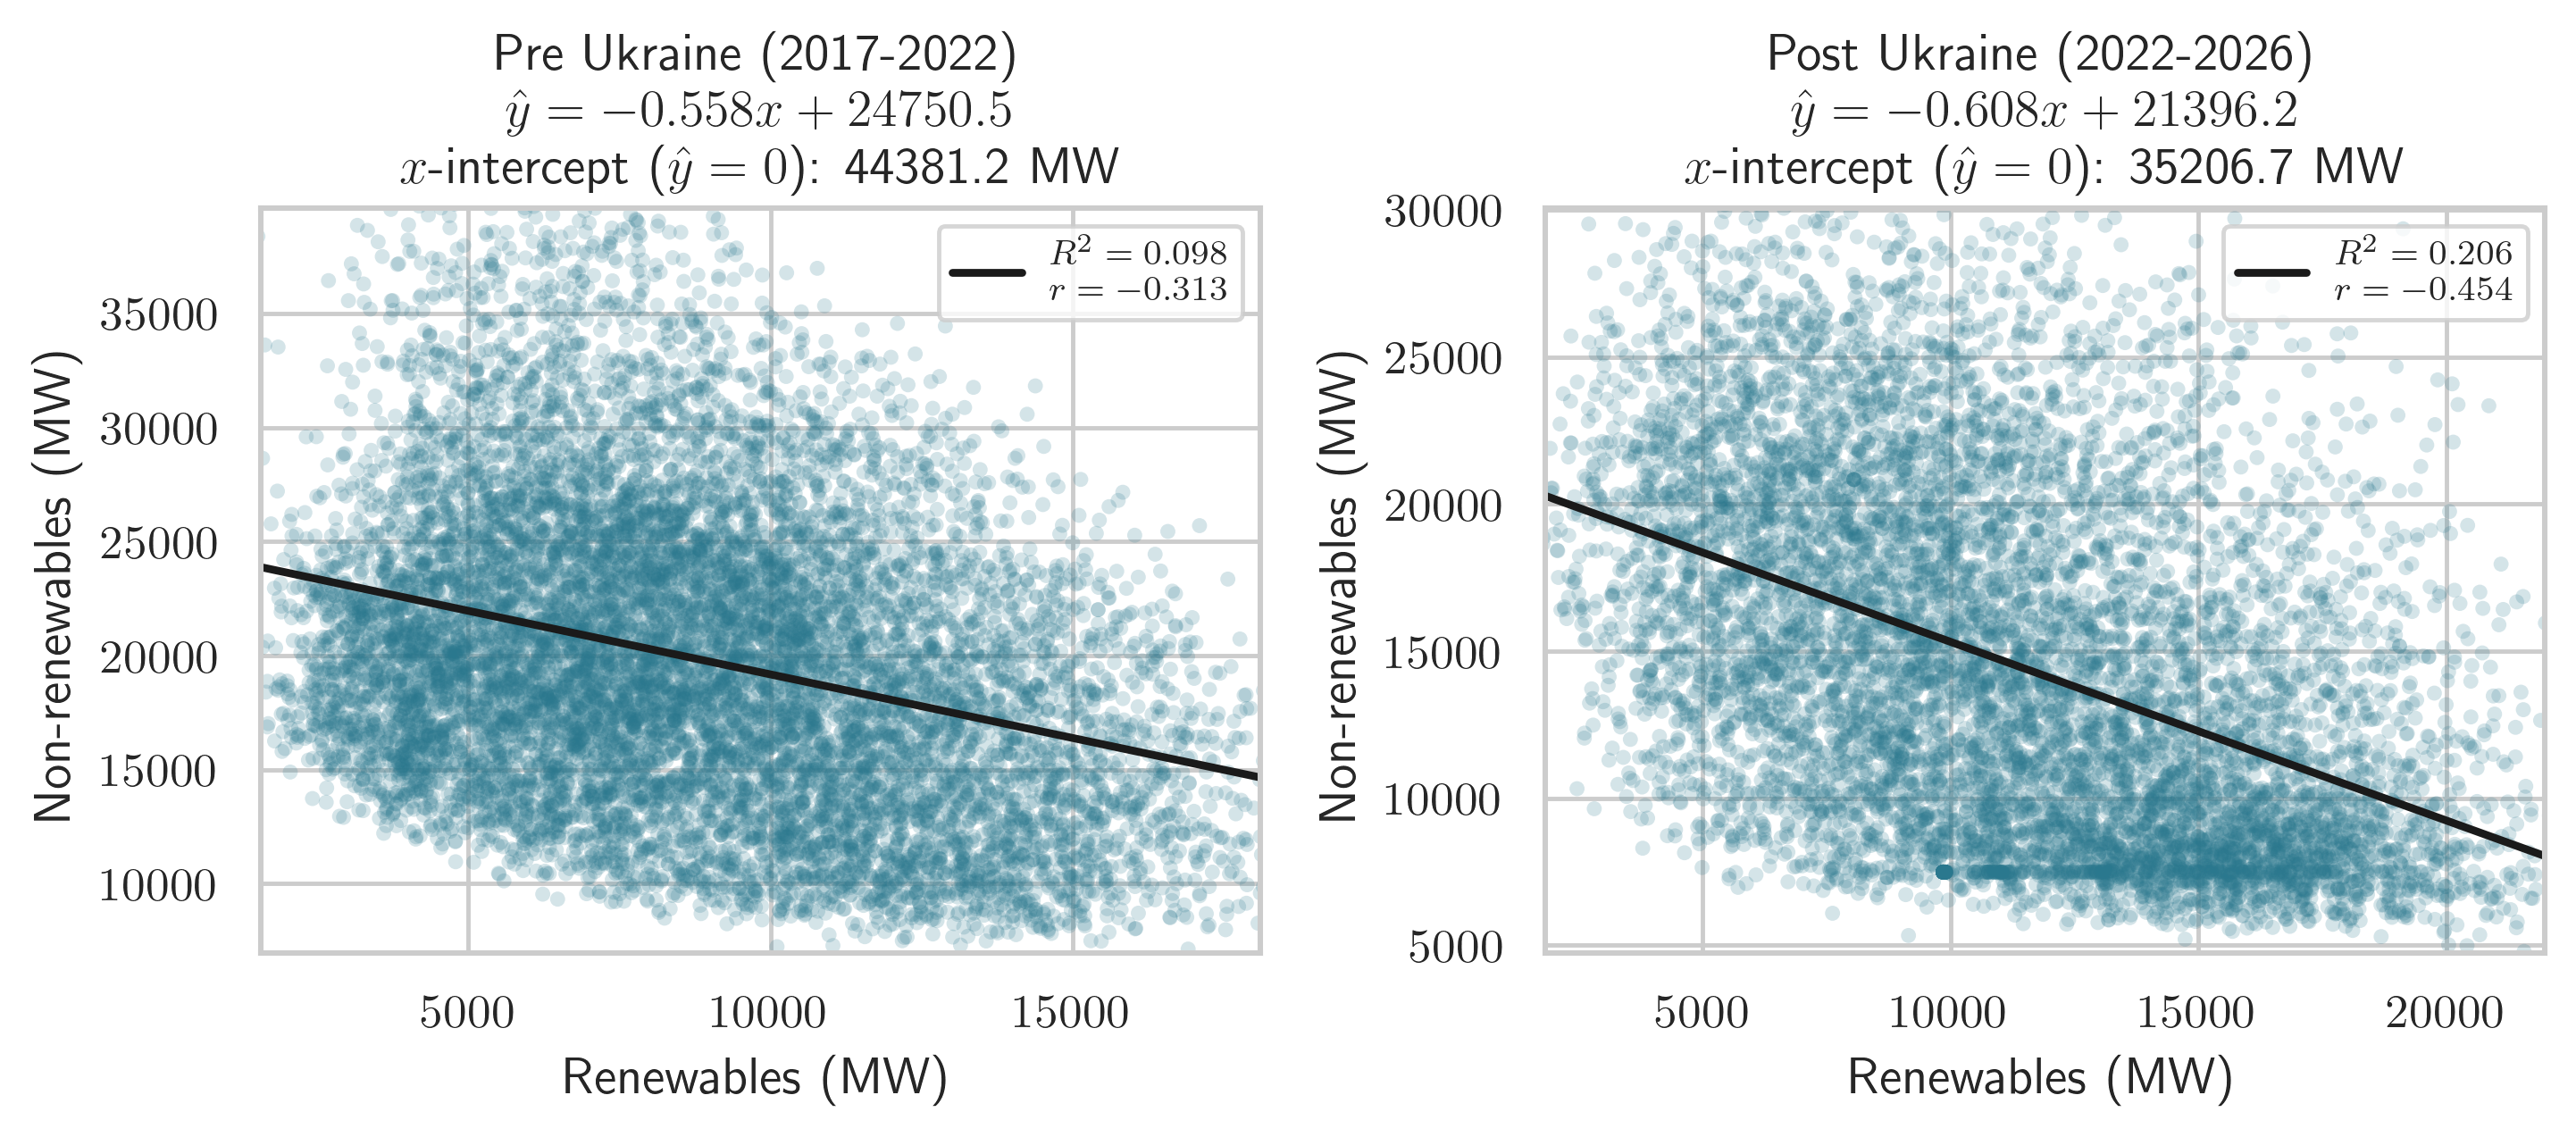

In [4]:
SCATTER_ALPHA = 0.20

era_order = ["PreUkraine", "PostUkraine"]
present_eras = [e for e in era_order if e in set(df["_era"])]
n_era = len(present_eras)
ncols = min(3, n_era)
nrows = int(np.ceil(n_era / ncols)) if n_era else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows), squeeze=False)
axes_flat = axes.ravel()
for ax, era in zip(axes_flat, present_eras):
    sub = df[df["_era"] == era]
    x = sub["_renewables"].to_numpy()
    y = sub["_a_non_renewables"].to_numpy()
    finite = np.isfinite(x) & np.isfinite(y)
    x_f = x[finite]
    y_f = y[finite]
    if len(x_f) == 0:
        ax.set_visible(False)
        continue
    if len(x_f) >= 10:
        x_lo, x_hi = np.nanpercentile(x_f, [1, 99])
        y_lo, y_hi = np.nanpercentile(y_f, [1, 99])
    else:
        x_lo, x_hi = np.nanmin(x_f), np.nanmax(x_f)
        y_lo, y_hi = np.nanmin(y_f), np.nanmax(y_f)
    if not np.isfinite(x_lo) or not np.isfinite(x_hi) or x_lo == x_hi:
        x_lo, x_hi = np.nanmin(x_f), np.nanmax(x_f)
    if not np.isfinite(y_lo) or not np.isfinite(y_hi) or y_lo == y_hi:
        y_lo, y_hi = np.nanmin(y_f), np.nanmax(y_f)
    x_pad = 0.06 * (x_hi - x_lo) if x_hi > x_lo else 1.0
    y_pad = 0.06 * (y_hi - y_lo) if y_hi > y_lo else 1.0
    x_lim = (x_lo - x_pad, x_hi + x_pad)
    y_lim = (y_lo - y_pad, y_hi + y_pad)
    ax.scatter(x_f, y_f, alpha=SCATTER_ALPHA, s=12, c="#2A788E", edgecolors="none")
    if len(x_f) >= 3:
        reg = linregress(x_f, y_f)
        xs = np.linspace(x_lim[0], x_lim[1], 100)
        r2 = reg.rvalue ** 2
        x_intercept = -reg.intercept / reg.slope if not np.isclose(reg.slope, 0.0) else np.nan
        x_intercept_text = f"{x_intercept:.1f} MW" if np.isfinite(x_intercept) else "undefined"
        ax.plot(
            xs,
            reg.intercept + reg.slope * xs,
            color="k",
            linewidth=1.8,
            label=f"$R^2={r2:.3f}$\n$r={reg.rvalue:.3f}$",
        )
        ax.set_title(
            f"{display_era_label(era)}\n"
            f"$\\hat{{y}} = {reg.slope:.3f}x + {reg.intercept:.1f}$\n"
            f"$x$-intercept ($\\hat{{y}}=0$): {x_intercept_text}"
        )
        ax.legend(loc="best", fontsize=8)
    else:
        ax.set_title(display_era_label(era))
    ax.set_xlim(*x_lim)
    ax.set_ylim(*y_lim)
    ax.set_xlabel("Renewables (MW)")
    ax.set_ylabel("Non-renewables (MW)")
for j in range(len(present_eras), len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_DIR / "a_scatter_renewables_vs_nonrenewables_pre_post_ukraine.png", dpi=PLOT_SAVE_DPI, bbox_inches="tight")
ALL_FIGS.append(fig)
plt.show()


### 2) n-day rolling OLS slope (non-renewables ~ renewables)


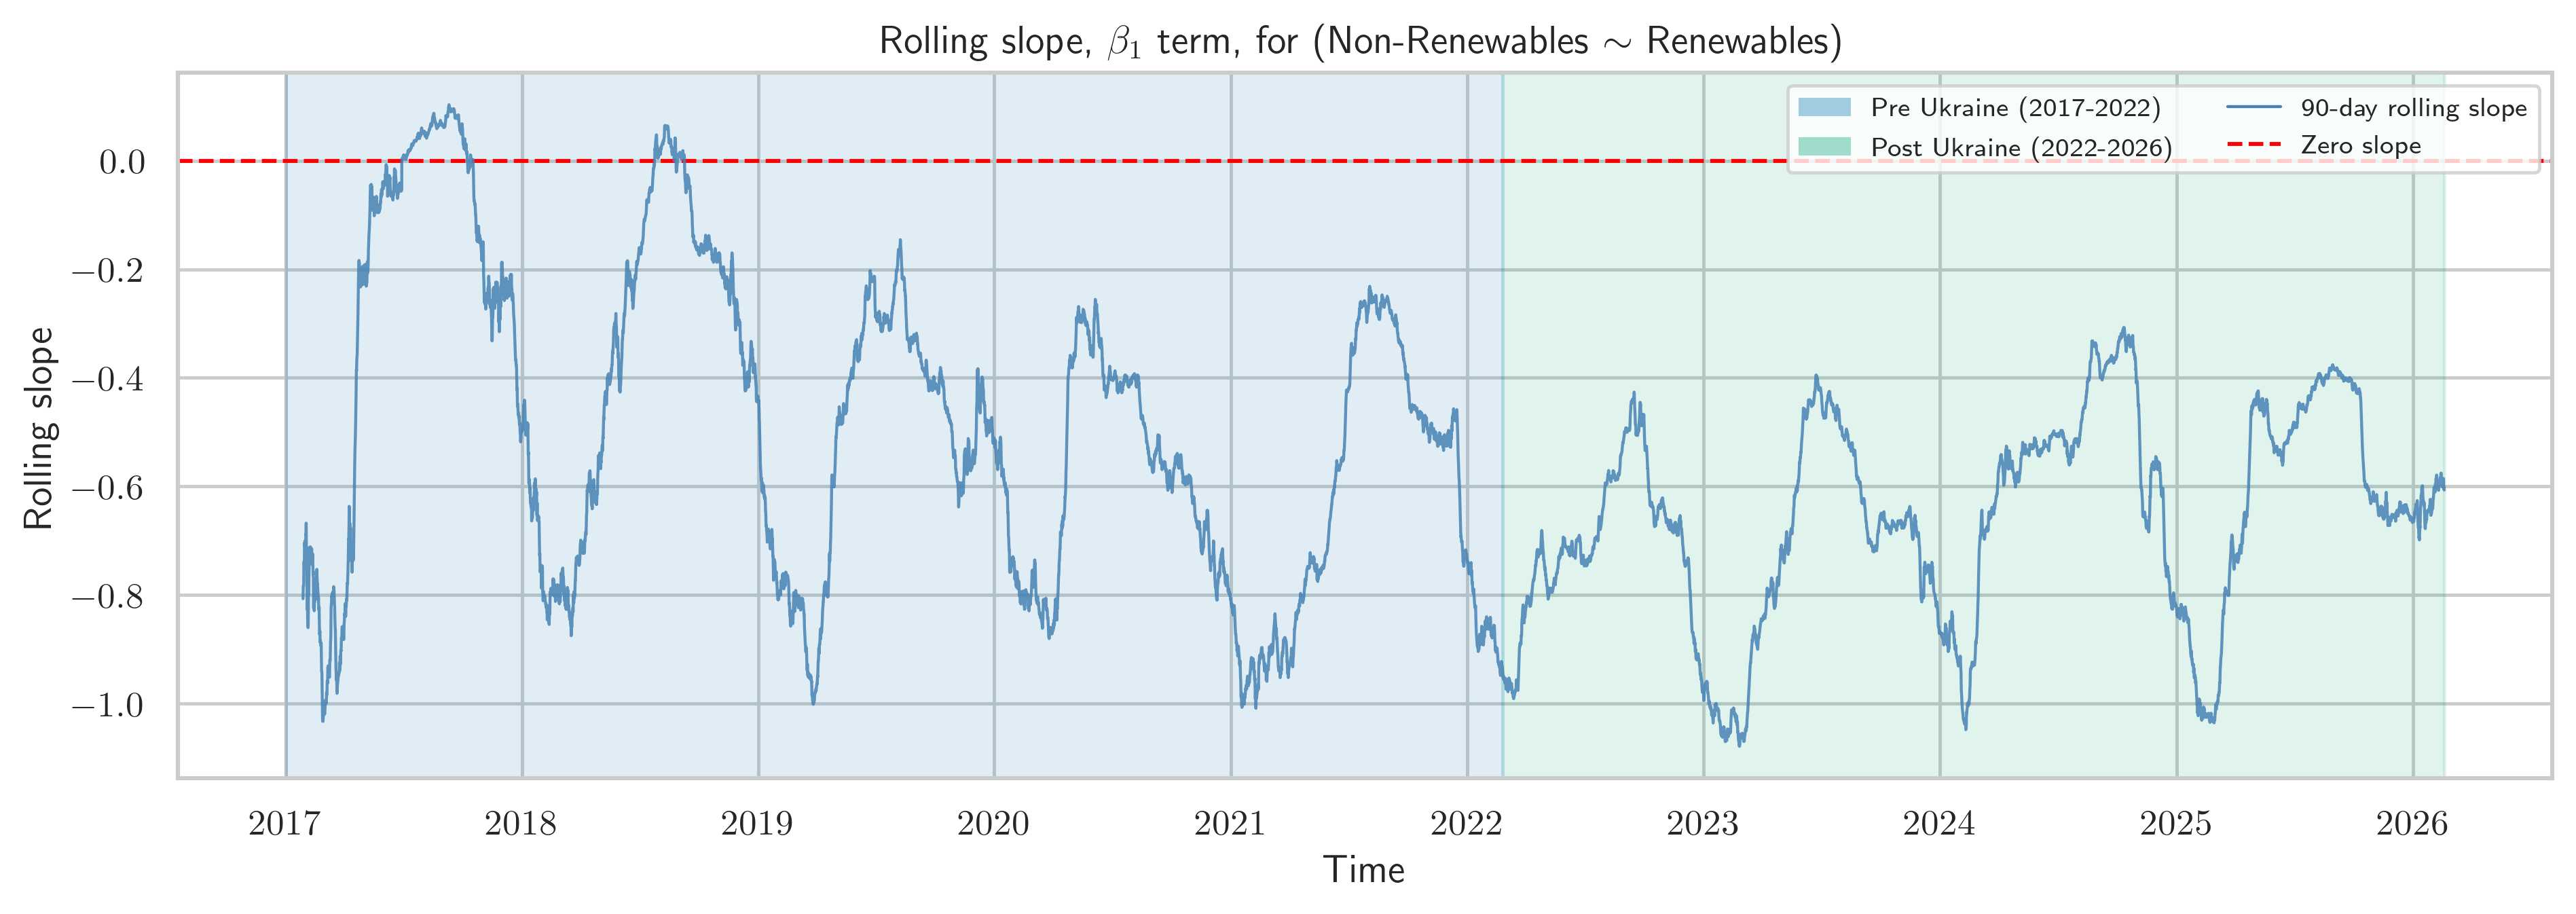

In [5]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(11, 3.8))
for e in present_eras:
    sub = df[df["_era"] == e]
    if len(sub):
        ax.axvspan(
            sub["timestamp"].min(),
            sub["timestamp"].max(),
            alpha=0.12,
            color=ERA_COLORS[e],
        )
ax.axhline(y=0, color="red", linestyle="--", linewidth=1.2, zorder=2)
ax.plot(df["timestamp"], df["_roll_slope"], color="steelblue", linewidth=0.9, alpha=0.85, zorder=3)
handles = [
    Patch(facecolor=ERA_COLORS[e], alpha=0.35, edgecolor="none", label=display_era_label(e))
    for e in present_eras
]
handles.append(Line2D([0], [0], color="steelblue", linewidth=0.9, label=f"{ROLLING_WINDOW_LENGTH}-day rolling slope"))
handles.append(Line2D([0], [0], color="red", linestyle="--", linewidth=1.2, label="Zero slope"))
ax.legend(handles=handles, loc="upper right", ncol=2, fontsize=8)
ax.set_ylabel("Rolling slope")
ax.set_xlabel("Time")
fig.tight_layout()
ax.set_title(r"Rolling slope, $\beta_1$ term, for (Non-Renewables $\sim$ Renewables)")
fig.savefig(OUT_DIR / "b_rolling_slope_beta1_pre_post_ukraine_timeseries.png", dpi=PLOT_SAVE_DPI, bbox_inches="tight")
ALL_FIGS.append(fig)
plt.show()


### 3) Slope histogram and per-era regression confidence intervals


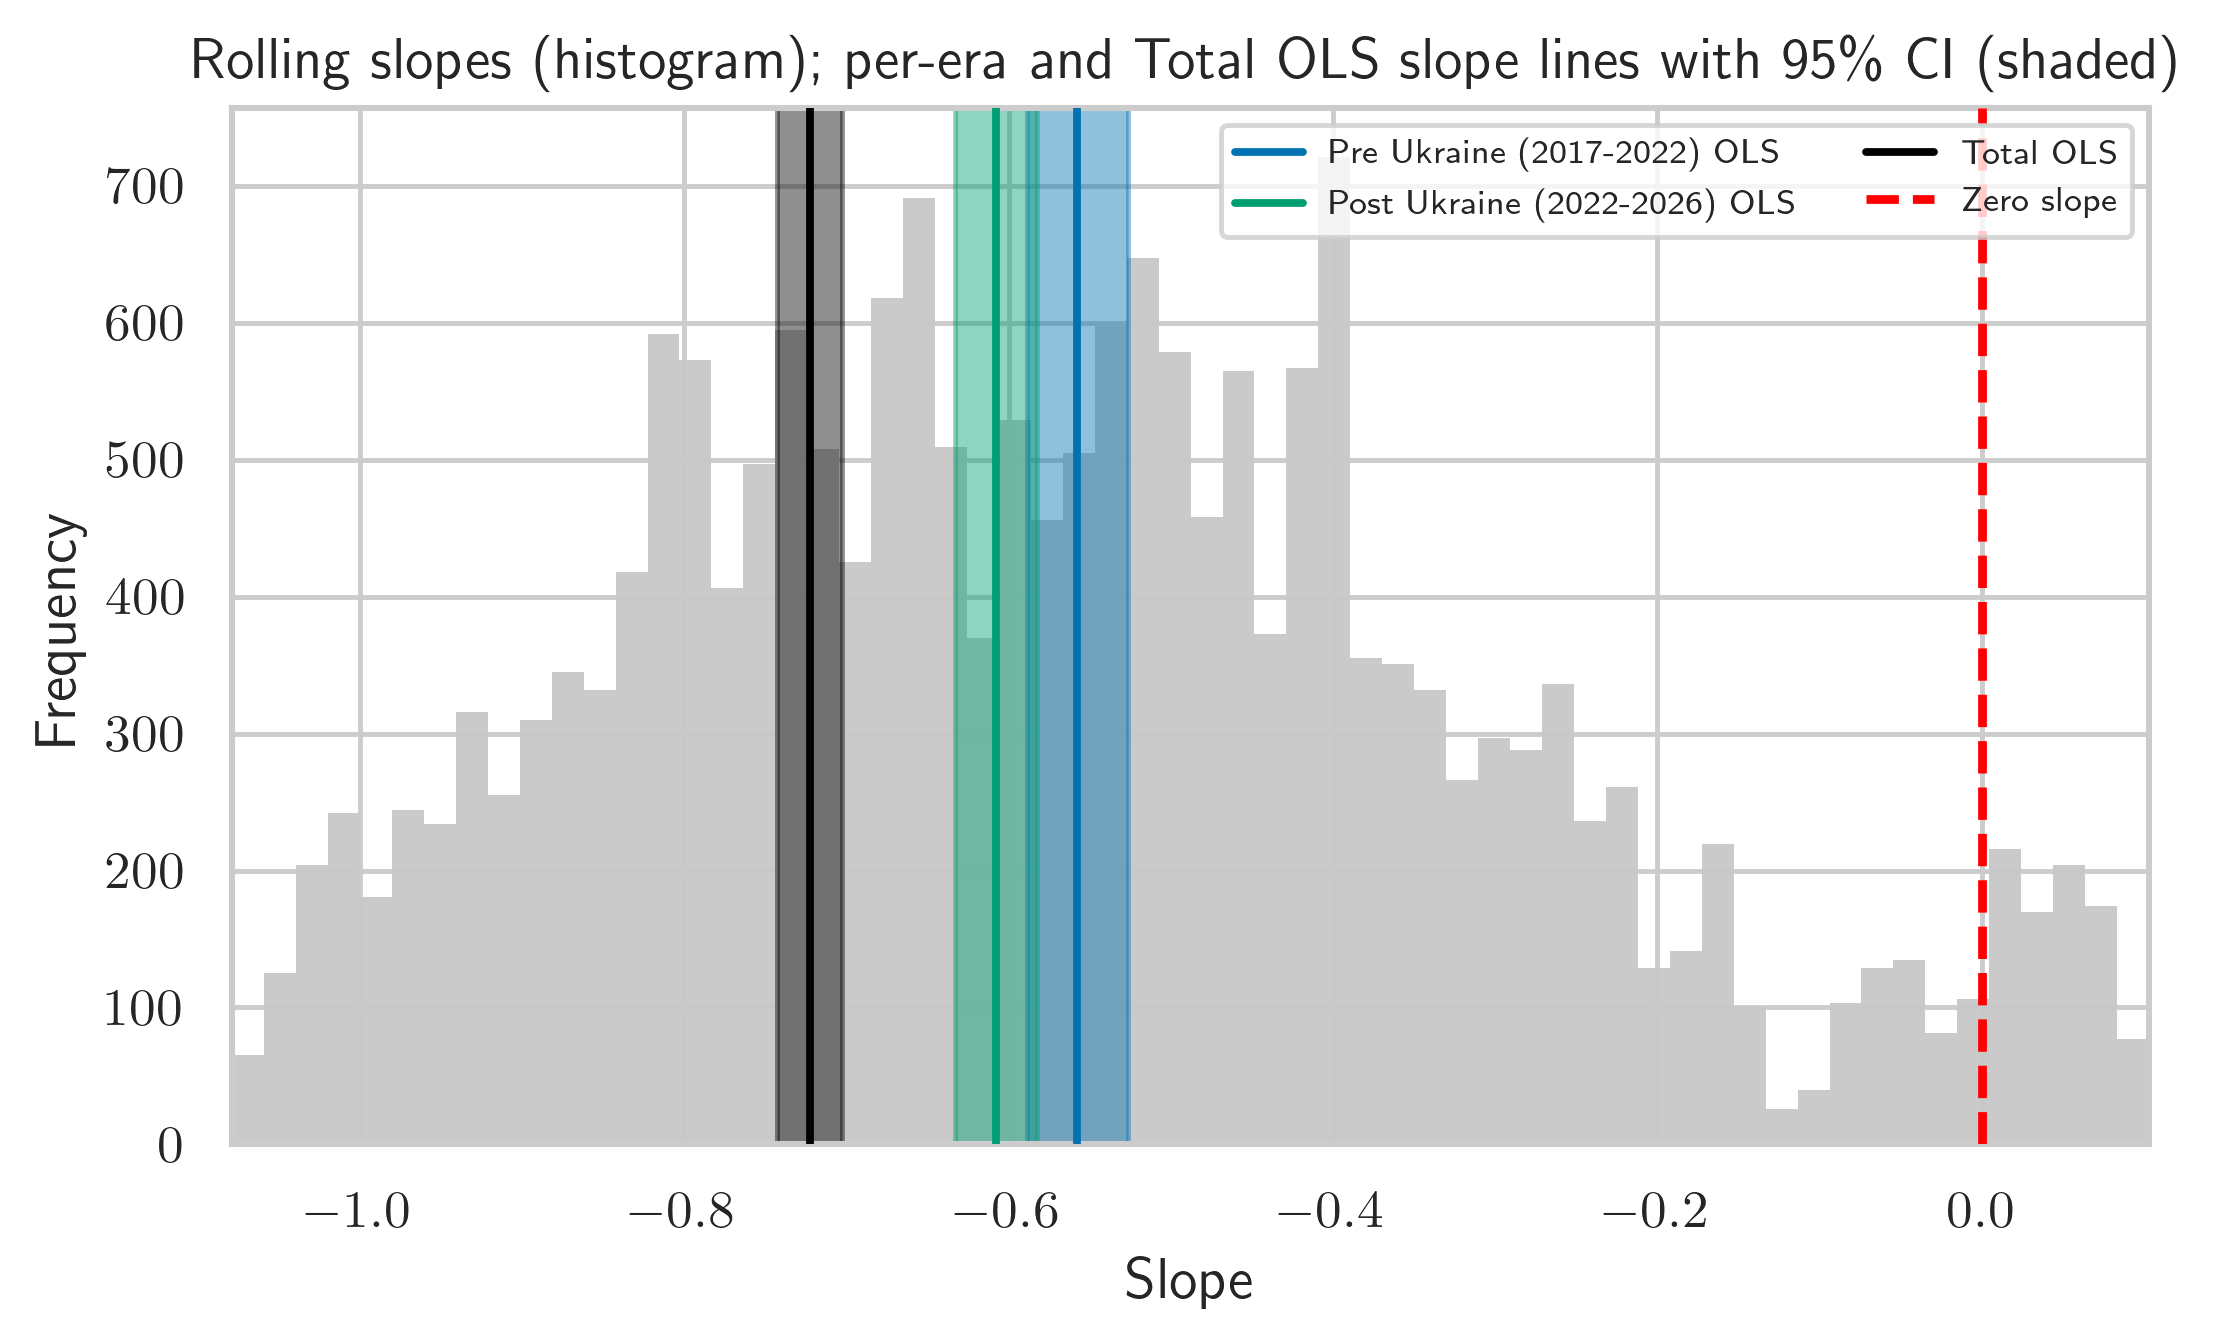

In [6]:
ALPHA = 0
SLOPE_XLIM_Q = (ALPHA, 1-ALPHA)
HIST_BAR_ALPHA = 0.95
sl = df["_roll_slope"].replace([np.inf, -np.inf], np.nan).dropna()
fig, ax = plt.subplots(figsize=(6.4, 4))
ax.hist(
    sl,
    bins=60,
    histtype="stepfilled",
    color="#c8c8c8",
    alpha=HIST_BAR_ALPHA,
    edgecolor="none",
    linewidth=0,
    zorder=1,
)
for era in present_eras:
    sub = df[df["_era"] == era]
    st = era_regression_table(sub["_renewables"].to_numpy(), sub["_a_non_renewables"].to_numpy())
    if np.isfinite(st["slope"]):
        color = ERA_COLORS[era]
        lo_ci, hi_ci = st["slope_ci_low"], st["slope_ci_high"]
        ax.axvspan(lo_ci, hi_ci, alpha=0.44, color=color, zorder=2)
        ax.axvline(0.5 * (lo_ci + hi_ci), color="white", linewidth=0.85, alpha=0.85, zorder=3, label="_nolegend_")
        ax.axvline(st["slope"], color=color, linewidth=1.6, label=f"{display_era_label(era)} OLS", zorder=4)
total_st = era_regression_table(df["_renewables"].to_numpy(), df["_a_non_renewables"].to_numpy())
if np.isfinite(total_st["slope"]):
    lo_ci, hi_ci = total_st["slope_ci_low"], total_st["slope_ci_high"]
    ax.axvspan(lo_ci, hi_ci, alpha=0.44, color="black", zorder=2)
    ax.axvline(0.5 * (lo_ci + hi_ci), color="white", linewidth=0.85, alpha=0.85, zorder=3, label="_nolegend_")
    ax.axvline(total_st["slope"], color="black", linewidth=1.6, label="Total OLS", zorder=4)
ax.axvline(0.0, color="red", linestyle="--", linewidth=1.8, label="Zero slope", zorder=4)
ax.legend(loc="upper right", fontsize=7, ncol=2)
if len(sl) > 0:
    lo, hi = np.nanquantile(sl, SLOPE_XLIM_Q)
    if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
        ax.set_xlim(lo, hi)
ax.set_xlabel("Slope")
ax.set_ylabel("Frequency")
ax.set_title(
    "Rolling slopes (histogram); per-era and Total OLS slope lines with 95\\% CI (shaded)"
)
fig.tight_layout()
fig.savefig(OUT_DIR / "c_rolling_slopes_histogram_pre_post_ukraine_ols_ci.png", dpi=PLOT_SAVE_DPI, bbox_inches="tight")
ALL_FIGS.append(fig)
plt.show()


### 3b) X-intercept histogram and per-era OLS x-intercept bootstrap confidence intervals


### 4) Per-era linear regression (includes r²)


In [7]:
out = []
for era in present_eras:
    sub = df[df["_era"] == era]
    st = era_regression_table(sub["_renewables"].to_numpy(), sub["_a_non_renewables"].to_numpy())
    st["era"] = display_era_label(era)
    out.append(st)
reg_df = pd.DataFrame(out).set_index("era")[
    ["n", "slope", "intercept", "r", "r2", "p", "stderr", "slope_ci_low", "slope_ci_high"]
]
print(reg_df.round(6).to_string())


                              n    slope     intercept         r        r2    p    stderr  slope_ci_low  slope_ci_high
era                                                                                                                   
Pre Ukraine (2017-2022)   11276 -0.55768  24750.536873 -0.313321  0.098170  0.0  0.015919     -0.588885      -0.526476
Post Ukraine (2022-2026)   8710 -0.60773  21396.177790 -0.453644  0.205793  0.0  0.012794     -0.632809      -0.582651


## Notebook B — Complementarity diagnostics

### 1) Correlation matrix


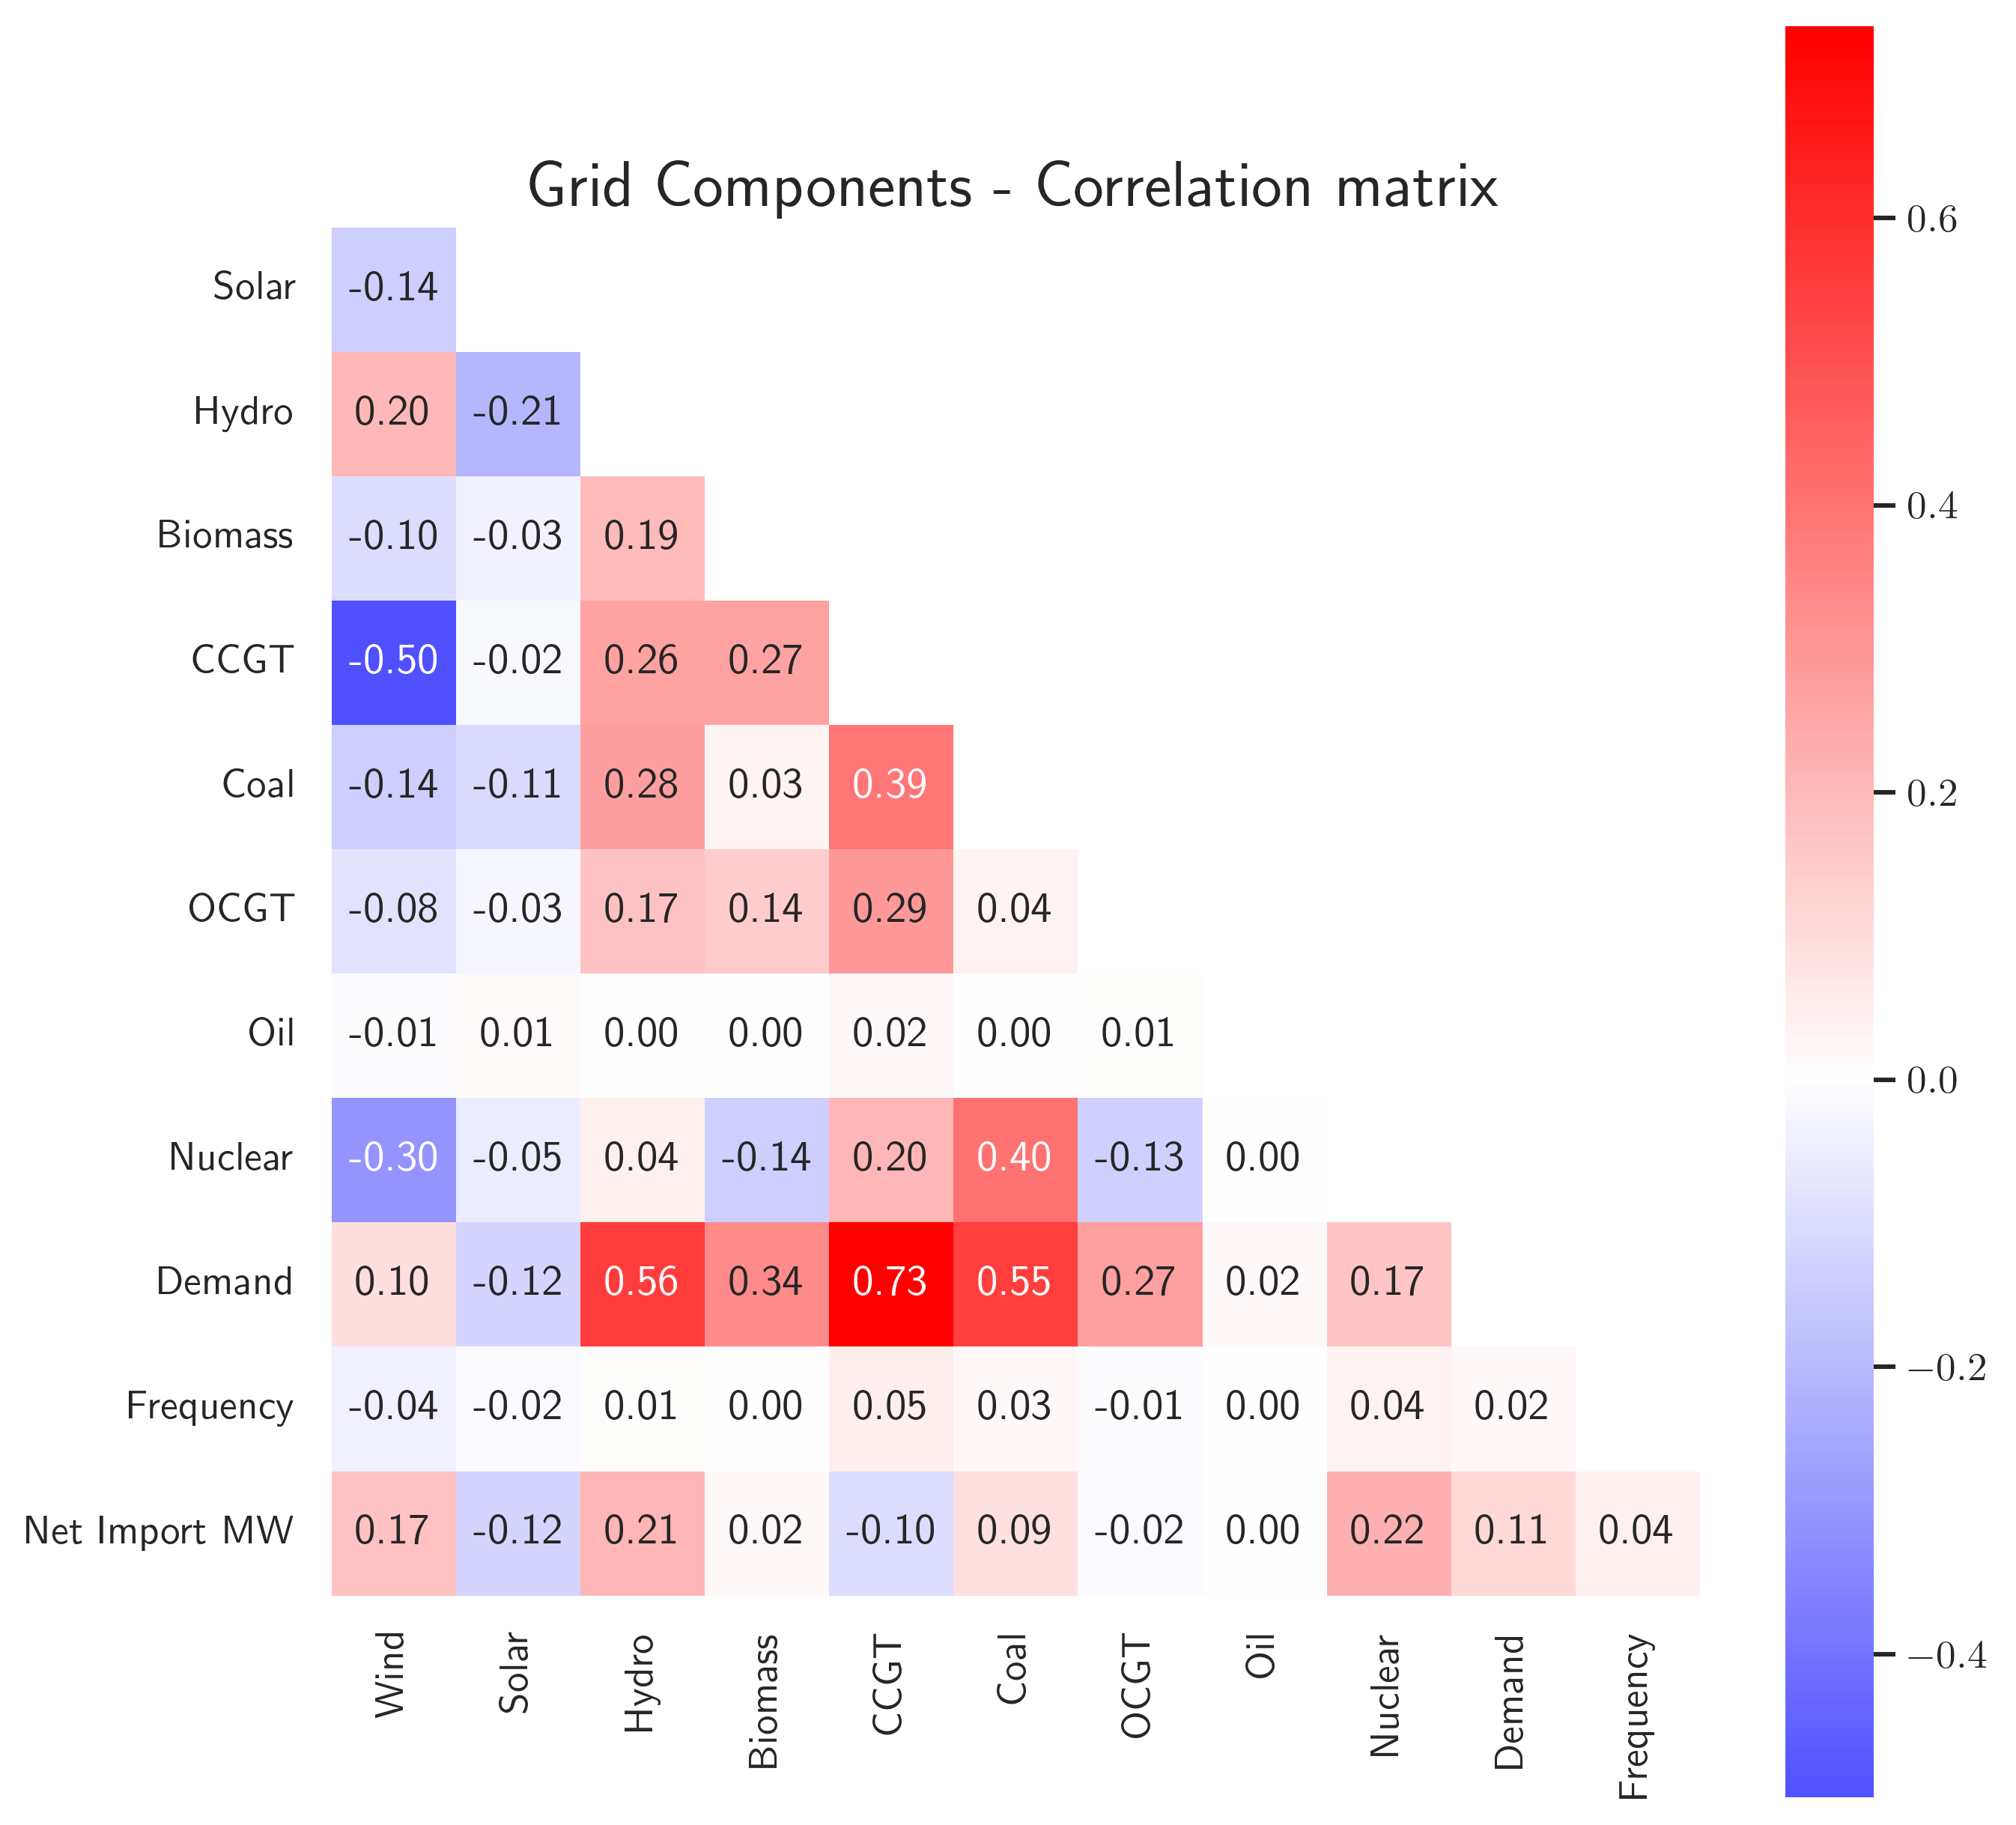

In [ ]:
SOURCE_COLS = [c for c in RENEW_COMPONENTS + FOSSIL_COMPONENTS + ["nuclear"] if c in df.columns]
SYSTEM_COLS = ["demand", "frequency", "net_import_mw"]
b_cols = SOURCE_COLS + [c for c in SYSTEM_COLS if c in df.columns]


def _pretty_label(name: str) -> str:
    acronyms = {"ccgt": "CCGT", "ocgt": "OCGT", "mw": "MW"}
    s = name.strip("_").replace("_", " ")
    parts = []
    for w in s.split():
        low = w.lower()
        parts.append(acronyms.get(low, w.capitalize()))
    return " ".join(parts)


cm = df[b_cols].corr().rename(index=_pretty_label, columns=_pretty_label)
cm_plot = cm.iloc[1:, :-1]
nr, nc = cm_plot.shape
mask = (np.arange(nr)[:, None] + 1) <= np.arange(nc)
fig, ax = plt.subplots(figsize=(0.55 * nc + 2, 0.5 * nr + 2))
sns.heatmap(cm_plot, annot=True, fmt=".2f", cmap="bwr", center=0, ax=ax, square=True, mask=mask)
ax.set_title("Grid Components - Correlation matrix", fontdict={"fontsize": 18})
ax.grid(False)
fig.tight_layout()
fig.savefig(OUT_DIR / "grid_components_correlation_matrix.png", dpi=PLOT_SAVE_DPI, bbox_inches="tight")
ALL_FIGS.append(fig)
plt.show()

## Notebook D — Net import state classification

Logistic regression on standardized numeric features; stratified train/test split.


 threshold  precision   recall       f1  accuracy
       0.2   0.928714 1.000000 0.963040  0.928714
       0.5   0.929842 0.999461 0.963396  0.929465
       0.8   0.940542 0.962833 0.951557  0.908954


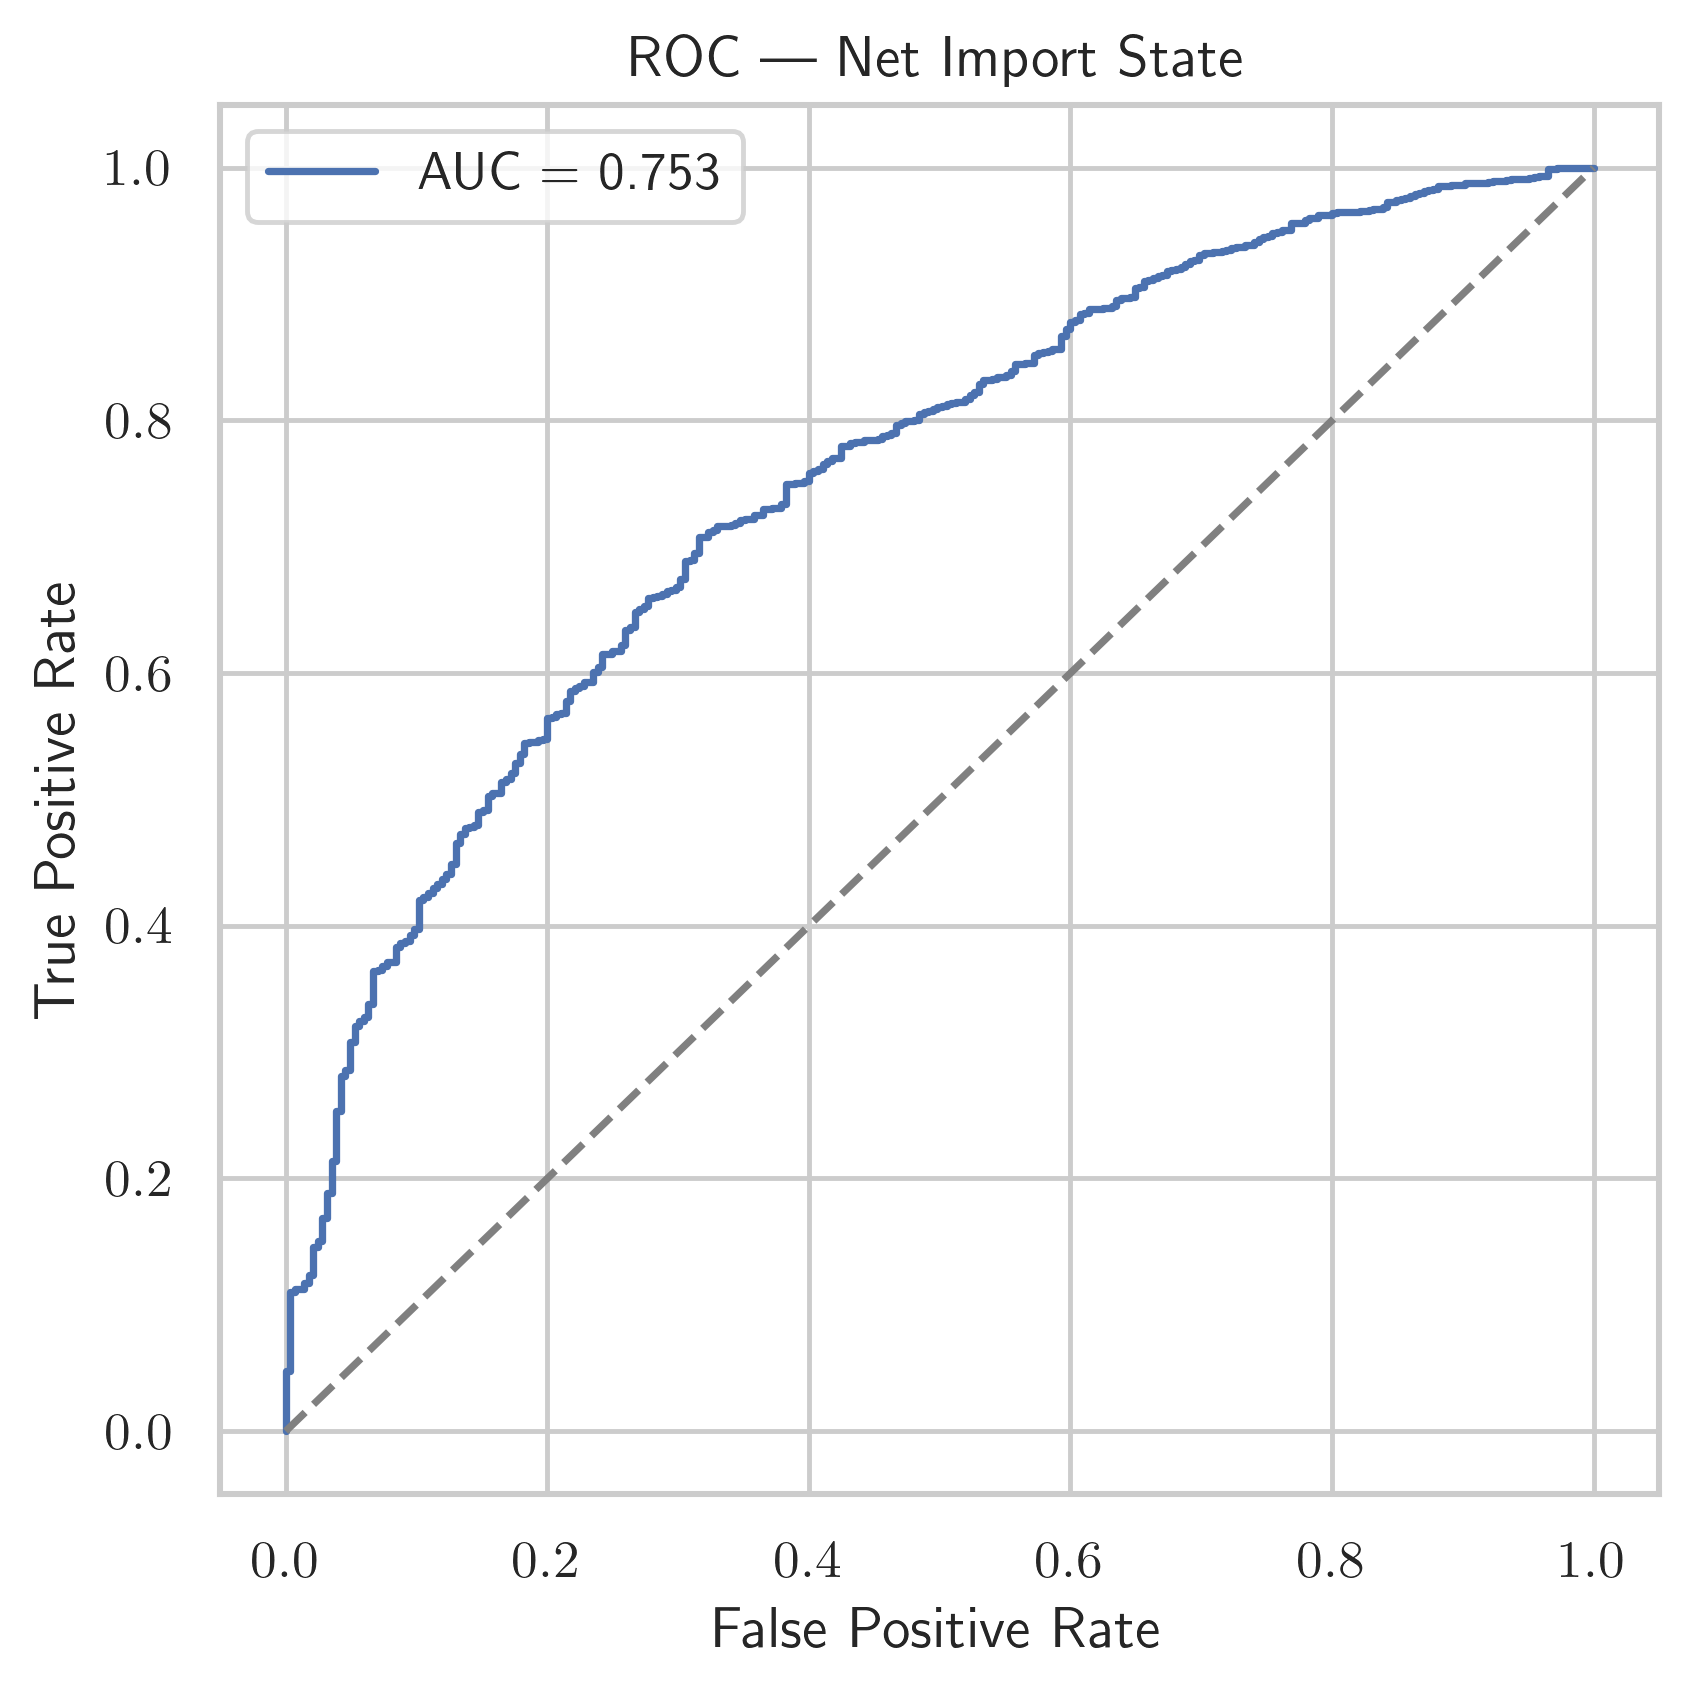

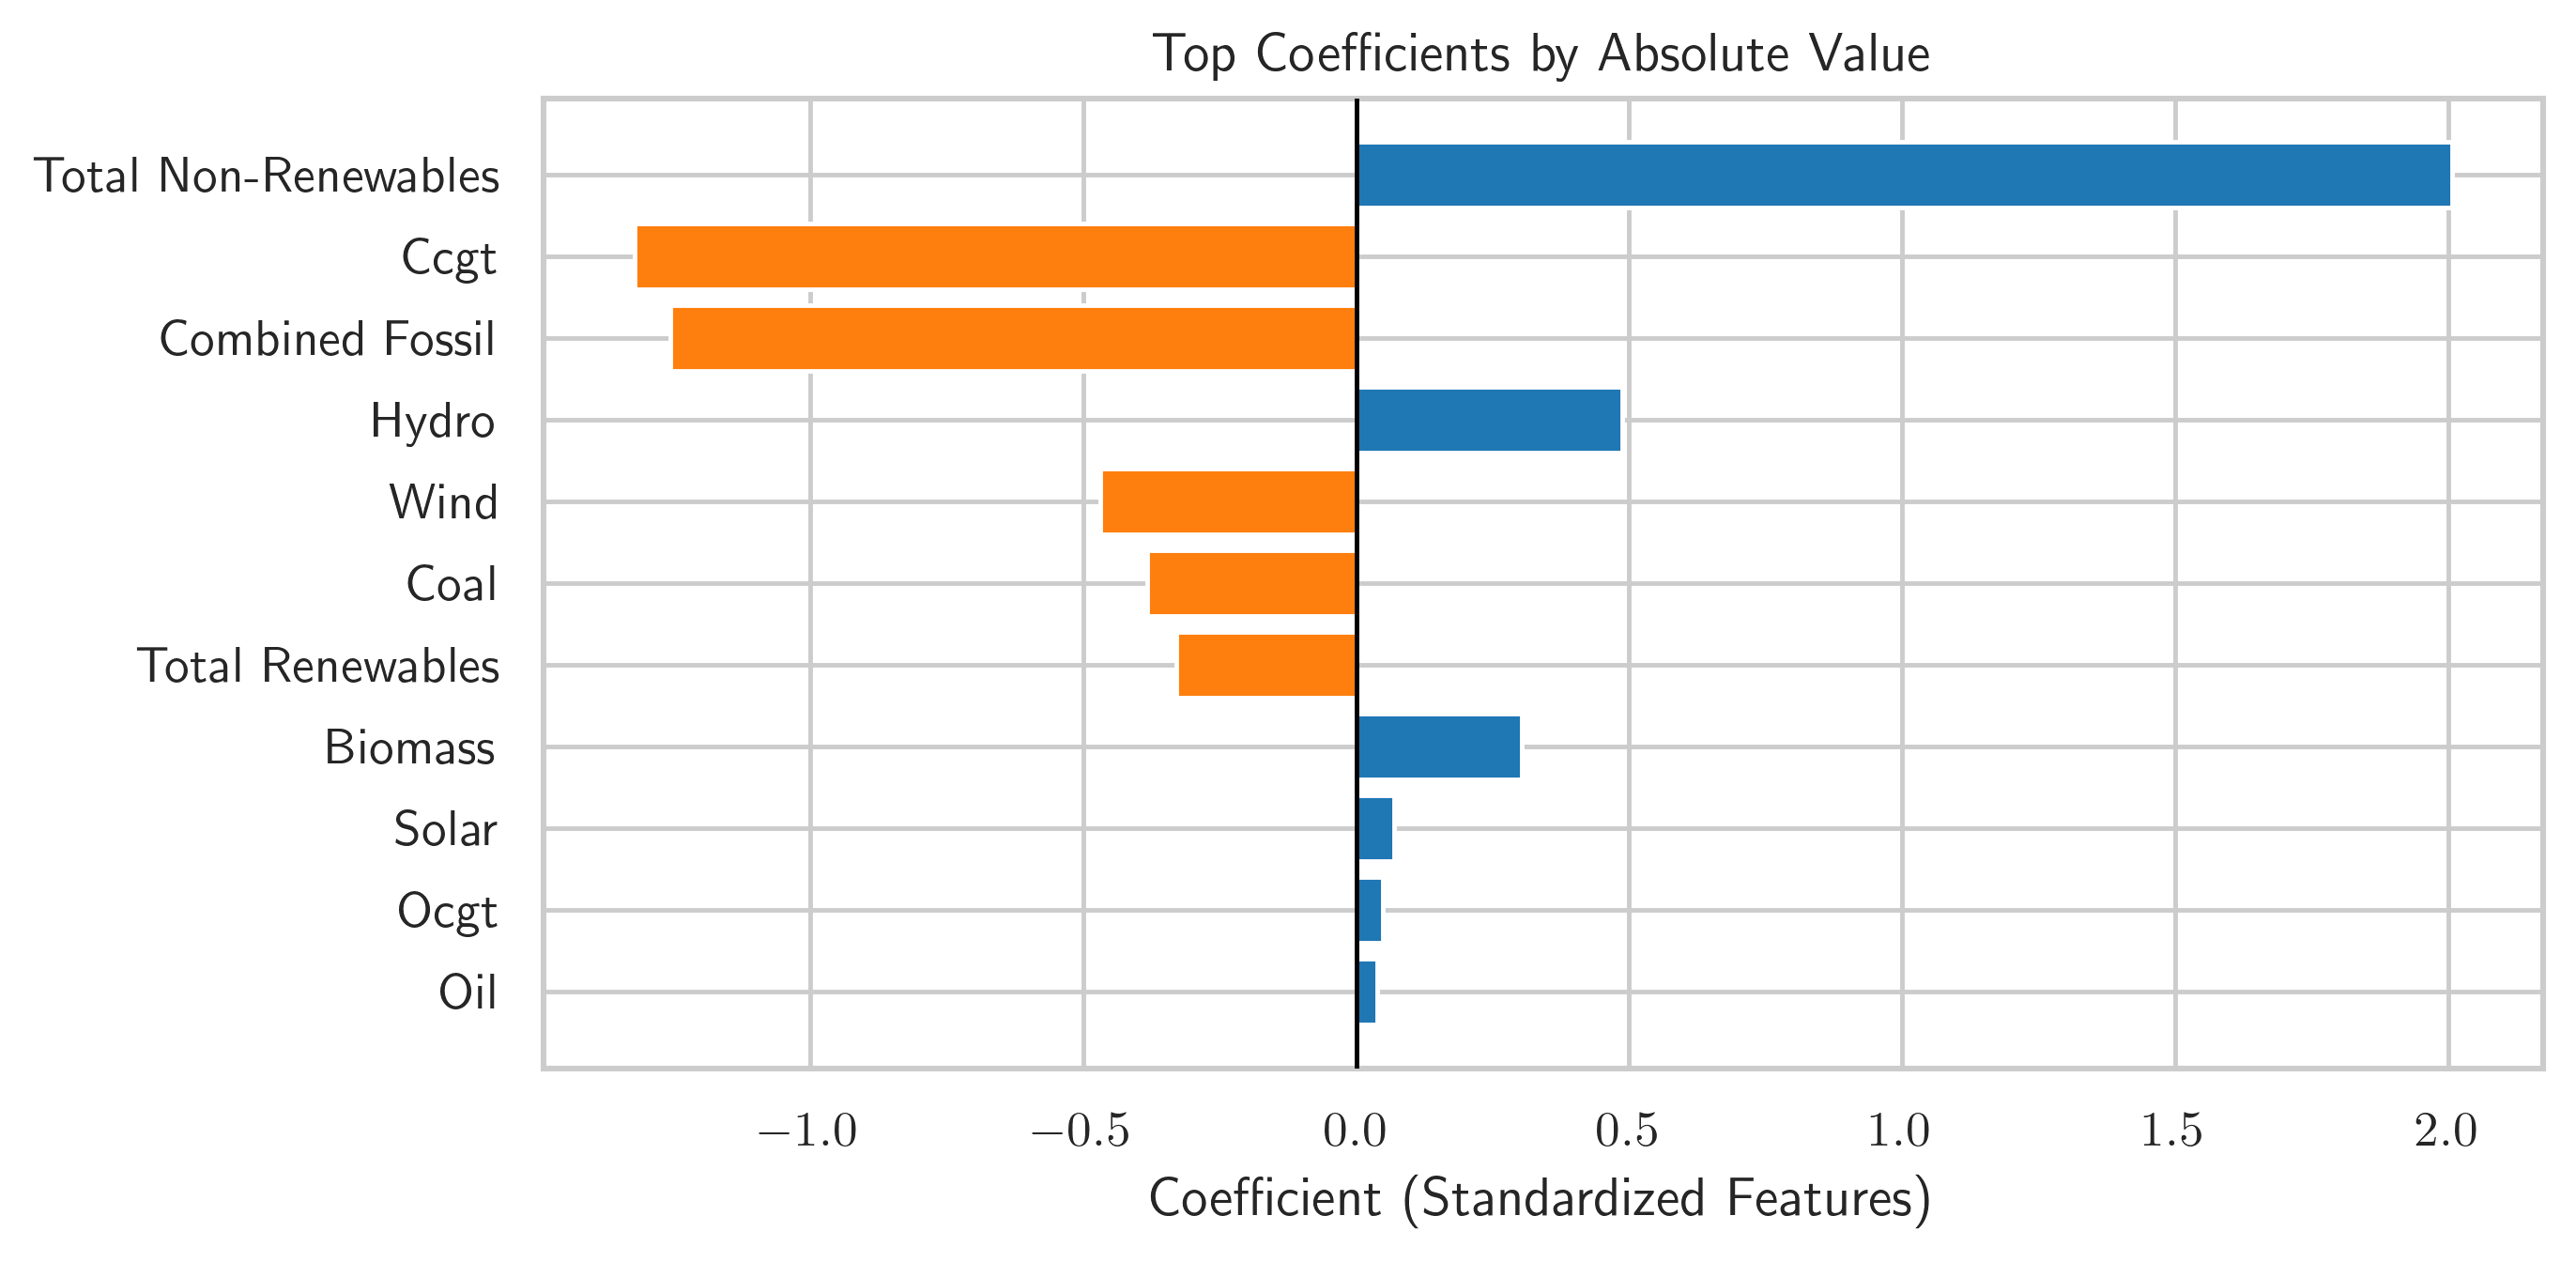

Features: 11; train 15988; test 3998


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y = resolve_net_import_target(df).astype(int)
approved_raw_sources = [
    "wind",
    "solar",
    "hydro",
    "biomass",
    "ccgt",
    "coal",
    "ocgt",
    "oil",
]
approved_source_only_aggregates = [
    "total_renewables",
    "renewables_total_b",
    "combined_fossil",
    "non_renewables_total_b",
    "_non_renewables",
]
allowed_candidates = [
    c for c in (approved_raw_sources + approved_source_only_aggregates) if c in df.columns
]
allowed_candidates = list(dict.fromkeys(allowed_candidates))
numeric_cols = set(df.select_dtypes(include=[np.number]).columns)
feat = [c for c in allowed_candidates if c in numeric_cols and c != "demand"]
if not feat:
    raise ValueError(
        "Notebook D has no valid source-only numeric features from the approved allowlist."
    )
X = df[feat].copy()
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].to_numpy(float)
y = y.loc[mask].to_numpy(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
clf = LogisticRegression(max_iter=5000, random_state=42, solver="lbfgs")
clf.fit(X_train_s, y_train)
proba = clf.predict_proba(X_test_s)[:, 1]
threshold_metrics_rows = []
for thr in (0.2, 0.5, 0.8):
    pred_thr = (proba >= thr).astype(int)
    threshold_metrics_rows.append(
        {
            "threshold": thr,
            "precision": precision_score(y_test, pred_thr, zero_division=0),
            "recall": recall_score(y_test, pred_thr, zero_division=0),
            "f1": f1_score(y_test, pred_thr, zero_division=0),
            "accuracy": accuracy_score(y_test, pred_thr),
        }
    )
threshold_metrics = pd.DataFrame(
    threshold_metrics_rows,
    columns=["threshold", "precision", "recall", "f1", "accuracy"],
)
print(threshold_metrics.to_string(index=False))

fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — Net Import State")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "d_roc_net_import_state.png", dpi=PLOT_SAVE_DPI, bbox_inches="tight")
ALL_FIGS.append(fig)
plt.show()

thresh = np.linspace(0.01, 0.99, 99)
prec = []
rec = []
f1 = []
acc = []
for t in thresh:
    pred = (proba >= t).astype(int)
    prec.append(precision_score(y_test, pred, zero_division=0))
    rec.append(recall_score(y_test, pred, zero_division=0))
    f1.append(f1_score(y_test, pred, zero_division=0))
    acc.append(accuracy_score(y_test, pred))

# fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(thresh, prec, label="precision")
# ax.plot(thresh, rec, label="recall")
# ax.plot(thresh, f1, label="F1")
# ax.plot(thresh, acc, label="accuracy")
# ax.set_xlabel("Threshold")
# ax.set_ylabel("Score")
# ax.legend()
# ax.set_title("Threshold sensitivity (test set)")
# fig.tight_layout()
# plt.show()

coef = clf.coef_.ravel()
order = np.argsort(np.abs(coef))[::-1][:25]
top_idx = order
FEAT_DISPLAY = {"_non_renewables": "Total Non-Renewables"}
display_feat = [
    FEAT_DISPLAY.get(name, name.replace("_", " ").strip().title())
    for name in np.array(feat)[top_idx][::-1]
]
coef_top = coef[top_idx][::-1]
fig, ax = plt.subplots(figsize=(8, max(4, 0.32 * len(top_idx))))
ax.barh(display_feat, coef_top, color=np.where(coef_top >= 0, "tab:blue", "tab:orange"))
ax.axvline(0.0, color="black", linewidth=1.0, zorder=5)
ax.set_xlabel("Coefficient (Standardized Features)")
ax.set_title("Top Coefficients by Absolute Value")
fig.tight_layout()
fig.savefig(OUT_DIR / "d_logistic_top_coefficients_absolute_value.png", dpi=PLOT_SAVE_DPI, bbox_inches="tight")
ALL_FIGS.append(fig)
plt.show()

print(f"Features: {len(feat)}; train {len(y_train)}; test {len(y_test)}")


In [10]:
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = OUT_DIR / "all_figures.pdf"
figs = [f for f in ALL_FIGS if f is not None]
seen = set()
unique_figs = []
for f in figs:
    fid = id(f)
    if fid not in seen:
        seen.add(fid)
        unique_figs.append(f)

if not unique_figs:
    print("No captured figures to export. Run plotting cells first.")
else:
    with PdfPages(pdf_path) as pdf:
        for fig in unique_figs:
            pdf.savefig(fig, bbox_inches="tight")
    print(f"Saved {len(unique_figs)} figures to {pdf_path}")

Saved 6 figures to /Users/j.p.barona/Code/FDS/FinalProject/out/all_figures.pdf
